Currently this does not pass `loadable_vars` explictly to `vz.open_virtual_mfdataset()`. It is relying on the internal functionality of virtualizarr to identify the 1D coordinate variables that should be passed to `loadable_vars`.  

For reference use Luis' notebook, which also demonstrates how to create VDS references using HTTPS access: https://notebooksharing.space/view/a0214376374af43776a54bf69b0b0308bbc0499fad345fcb5eb70e9ad9cf46c6#displayOptions=

In [29]:
import earthaccess as ea
import xarray as xr
import zarr
from urllib.parse import urlparse
import fsspec
import warnings
import logging

import dask
from dask.distributed import Client, LocalCluster
from coiled import Cluster as CoiledCluster
import numpy as np

import icechunk
import obstore
from obstore.auth.earthdata import NasaEarthdataCredentialProvider # Only S3 links access in-region
from obstore.store import HTTPStore, S3Store
from virtualizarr.parsers import DMRPPParser, NetCDF3Parser, HDFParser
from virtualizarr.registry import ObjectStoreRegistry
import virtualizarr as vz

for _ in (ea, vz, zarr, xr, obstore, dask, fsspec, icechunk):
    print(f"{_.__name__}: {_.__version__}")

earthaccess: 0.16.0
virtualizarr: 2.4.0
zarr: 3.1.5
xarray: 2025.6.1
obstore: 0.8.2
dask: 2024.5.2
fsspec: 2025.7.0
icechunk: 1.1.21


In [2]:
auth = ea.login()

Enter your Earthdata Login username:  deanh808
Enter your Earthdata password:  ········


## 1. Create Dask cluster

In [3]:
cloud_opts = {
    "region": "us-west-2",
    "worker_vm_types": ["t3a.medium"],
    "spot_policy": "spot_with_fallback",
    # "arm": False,
    "name": "test-vd",
    "environ": {"EARTHDATA_TOKEN": auth.token["access_token"]}
}

def create_dask_cluster(environment="local",
                        n_workers=4,
                        cloud_opts={}):
    if environment=="local":
        import logging
        print("Creating new local Dask client")
        cluster = LocalCluster(
            n_workers=n_workers,
            threads_per_worker=1,
            silence_logs=logging.ERROR)
    else:
        print("Creating new Coiled Dask client")
        cluster = CoiledCluster(n_workers=n_workers,
                                **cloud_opts)    

    client = Client(cluster)
    return (client, cluster)

In [4]:
import multiprocessing

# Check how many cpu's are on this VM:
print("CPU count =", multiprocessing.cpu_count())

CPU count = 8


In [5]:
if "client" not in locals() or "cluster" not in locals():
    client, cluster = create_dask_cluster(
        environment="local",
        n_workers=8,
        cloud_opts=cloud_opts)
client

Creating new local Dask client


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://cluster-qfxeg.dask.host/jupyter/proxy/8787/status,
Dashboard: https://cluster-qfxeg.dask.host/jupyter/proxy/8787/status,Workers: 8
Total threads: 8,Total memory: 29.76 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35937,Workers: 8
Dashboard: https://cluster-qfxeg.dask.host/jupyter/proxy/8787/status,Total threads: 8
Started: Just now,Total memory: 29.76 GiB
Comm: tcp://127.0.0.1:42887,Total threads: 1
Dashboard: https://cluster-qfxeg.dask.host/jupyter/proxy/34987/status,Memory: 3.72 GiB
Nanny: tcp://127.0.0.1:41377,


#### Following code is needed to give EDL creds explicitly to each Dask worker

In [6]:
def silence_worker_warnings_and_auth(token):
    import warnings
    import logging
    # local instance of earthaccess is explicitely authenticated
    import earthaccess as ea
    import os

    if token:
        os.environ["EARTHDATA_TOKEN"]= token
        auth = ea.login(strategy="environment")
    
    warnings.filterwarnings("ignore")
    for name in ["distributed", "xarray", "py.warnings", "fsspec", "h5netcdf", "h5py"]:
        logging.getLogger(name).setLevel(logging.ERROR)

In [7]:
%%capture
client.run(silence_worker_warnings_and_auth, auth.token["access_token"])

## 2. Create multi-collection VDS for all monthly snapshot collections

## 2.1 Create combined VDS ref files for each collection

In [ ]:
shortnames_monthly = [
    "SASSIE_ECCO_L4_OBP_SSH_LLC1080GRID_SNAPSHOT_V1R1",
    "SASSIE_ECCO_L4_TEMP_SALINITY_LLC1080GRID_SNAPSHOT_V1R1",
    "SASSIE_ECCO_L4_SEA_ICE_CONC_THICK_VEL_LLC1080GRID_SNAPSHOT_V1R1",
]

In [ ]:
%%time

vds_s3_list = []

for sn in shortnames_monthly:
    
    print(sn)

    auth = ea.login()
    
    ## 1. Get granule metadata and s3 links ------------------------------------------------
    results = ea.search_data(
        short_name=sn,
        provider="POCLOUD",
        cloud_hosted=True,
    )
        # S3 links
    granule_data_urls_s3 = [
        granule.data_links(access="direct")[0] for granule in results
    ]
    print("Number of file found: ", len(results))

    
    ## 2. Setup store registry -------------------------------------------------------------
    access = "direct"
    credentials_endpoint = "https://archive.podaac.earthdata.nasa.gov/s3credentials"
        # Get bucket location of granules from the first granule's metadata:
    parsed_url = urlparse(results[0].data_links(access=access)[0])
    bucket = parsed_url.netloc
    
    s3_store = S3Store(
        bucket=bucket,
        region="us-west-2",
        credential_provider=NasaEarthdataCredentialProvider(credentials_endpoint, auth=auth.token["access_token"]),
        virtual_hosted_style_request=False,
        client_options={"allow_http": True},
    )
    s3_obstore_registry = ObjectStoreRegistry({f"s3://{bucket}": s3_store})


    ## 3. Setup any data preprocessing and kwargs to pass to xr.combine_nested() -------------
        # not doing any preprocessing currently:
    def preprocess_func(ds):
        return ds
    
    xr_combine_nested_kwargs = {
        "concat_dim": "time",  # Concatenate files along the time dimension
        "preprocess": preprocess_func, # Normalize the dataframe 
        "data_vars": "minimal",  # Only load data variables that include the concat_dim
        "coords": "minimal",  # Only load coordinate variables that include the concat_dim
        "compat": "override",  # Avoid coordinate conflicts by picking the first
        "combine_attrs": "override",  # Avoid attribute conflicts by picking the first
    }


    ## 4. Create VDS reference - does the single file references and concatentation
    ## in one function ------------------------------------------------------------------------
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="Numcodecs codecs*",
            category=UserWarning,
        )
        group = None
        vds_s3 = vz.open_virtual_mfdataset(
            urls=granule_data_urls_s3,
            registry=s3_obstore_registry,
            parser=HDFParser(),
            decode_times=False,
            parallel="dask",
            combine="nested",
            **xr_combine_nested_kwargs,
        )

    vds_s3_list.append(vds_s3)

## 2.2 Multi-collection VDS

In [63]:
## Combine all into single VDS:
vds_monthly_composite_s3 = xr.combine_nested(
    vds_s3_list, concat_dim=None, 
    compat='override', combine_attrs='drop_conflicts'
)

In [64]:
vds_monthly_composite_s3

<xarray.Dataset> Size: 124GB
Dimensions:   (time: 85, j: 1080, i: 1800, nb: 4, k: 90, k_u: 90, k_l: 90,
               k_p1: 91, nv: 2, i_g: 1800, j_g: 1080)
Coordinates: (12/22)
  * time      (time) int32 340B 193596 194268 195012 ... 253476 254220 254964
  * j         (j) int32 4kB 0 1 2 3 4 5 6 ... 1073 1074 1075 1076 1077 1078 1079
  * i         (i) int32 7kB 0 1 2 3 4 5 6 ... 1793 1794 1795 1796 1797 1798 1799
    XC        (j, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=floa...
    YC        (j, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=floa...
    XC_bnds   (j, i, nb) float32 31MB ManifestArray<shape=(1080, 1800, 4), dt...
    ...        ...
  * j_g       (j_g) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * i_g       (i_g) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
    XU        (j, i_g) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    YU        (j, i_g) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    XV        (j_g, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    YV        (j_g, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
Dimensions without coordinates: nb, nv
Data variables:
    ETAN      (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    PHIBOT    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SALT      (time, k, j, i) float32 59GB ManifestArray<shape=(85, 90, 1080,...
    THETA     (time, k, j, i) float32 59GB ManifestArray<shape=(85, 90, 1080,...
    SIarea    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIheff    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIhsnow   (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIuice    (time, j, i_g) float32 661MB ManifestArray<shape=(85, 1080, 180...
    SIvice    (time, j_g, i) float32 661MB ManifestArray<shape=(85, 1080, 180...
    sIceLoad  (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
Attributes: (12/47)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    time_coverage_resolution:          PT0S
    geospatial_vertical_max:           0.0
    geospatial_vertical_min:           -7000.0
    geospatial_vertical_positive:      up
    geospatial_vertical_resolution:    variable
    geospatial_vertical_units:         meter

In [67]:
## Modify/add some attributes:
vds_monthly_composite_s3.attrs['time_coverage_start'] = '2014-01-15T00:00:00Z'
vds_monthly_composite_s3.attrs['time_coverage_end'] = '2021-02-08T00:00:00Z'
vds_monthly_composite_s3.attrs['identifier_product_doi'] = "https://doi.org/10.5067/SEL1D-DUG11"
vds_monthly_composite_s3.attrs['date_created'] = "2026-03-21T00:00:00Z"
vds_monthly_composite_s3.attrs['history'] = "Virtual layer on top of the initial release of the ECCO N1 SASSIE Ocean-Sea Ice Simulation data, for all monthly snapshot collections."
vds_monthly_composite_s3.attrs['comment'] = (
    vds_monthly_composite_s3.attrs['comment']
    + " This is a virtual layer on top of the original data, for all monthly snapshot datasets - it allows the user to access all"
    + " the data files from all datasets as if they were in a single, composite dataset."
)

## 2.3 Duplicate to create a VDS with HTTP endpoints

In [59]:
from pathlib import Path

In [60]:
def s3_to_http_url(old_s3_path: str) -> str:
    """
    Change S3 endpoint to HTTP.
    """
    from pathlib import Path

    https_base = "https://archive.podaac.earthdata.nasa.gov/"
    return str(https_base + old_s3_path.split("//")[-1])

In [68]:
vds_monthly_composite_http = vds_monthly_composite_s3.vz.rename_paths(s3_to_http_url)

In [69]:
vds_monthly_composite_http

<xarray.Dataset> Size: 124GB
Dimensions:   (time: 85, j: 1080, i: 1800, nb: 4, k: 90, k_u: 90, k_l: 90,
               k_p1: 91, nv: 2, i_g: 1800, j_g: 1080)
Coordinates: (12/22)
  * time      (time) int32 340B 193596 194268 195012 ... 253476 254220 254964
  * j         (j) int32 4kB 0 1 2 3 4 5 6 ... 1073 1074 1075 1076 1077 1078 1079
  * i         (i) int32 7kB 0 1 2 3 4 5 6 ... 1793 1794 1795 1796 1797 1798 1799
    XC        (j, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=floa...
    YC        (j, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=floa...
    XC_bnds   (j, i, nb) float32 31MB ManifestArray<shape=(1080, 1800, 4), dt...
    ...        ...
  * j_g       (j_g) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * i_g       (i_g) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
    XU        (j, i_g) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    YU        (j, i_g) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    XV        (j_g, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    YV        (j_g, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
Dimensions without coordinates: nb, nv
Data variables:
    ETAN      (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    PHIBOT    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SALT      (time, k, j, i) float32 59GB ManifestArray<shape=(85, 90, 1080,...
    THETA     (time, k, j, i) float32 59GB ManifestArray<shape=(85, 90, 1080,...
    SIarea    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIheff    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIhsnow   (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIuice    (time, j, i_g) float32 661MB ManifestArray<shape=(85, 1080, 180...
    SIvice    (time, j_g, i) float32 661MB ManifestArray<shape=(85, 1080, 180...
    sIceLoad  (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
Attributes: (12/49)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    geospatial_vertical_min:           -7000.0
    geospatial_vertical_positive:      up
    geospatial_vertical_resolution:    variable
    geospatial_vertical_units:         meter
    identifier_product_doi:            https://doi.org/10.5067/SEL1D-DUG11
    date_created:                      2026-03-21T00:00:00Z

## 2.4 Save to Icechunk stores

One store each for the S3 and HTTP endpoints.

In [ ]:
## Only works to create icechunk store for s3 endpoints currently -------------------------------

def create_local_icechunk_repo_httpaccess(repo_name: str, vcc_http_base: str):
    """
    Creates an icechunk repository locally, with pointers to data chunks in HTTPS locations.

    Inputs
    ------
    * repo_name (str): path to icechunk repo.
    """
    storage = icechunk.local_filesystem_storage(path=repo_name)
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            vcc_http_base,
            icechunk.http_store(options={})
        )
    )
    return icechunk.Repository.create(storage, config)

In [32]:
## Only works to create icechunk store for s3 endpoints currently -------------------------------

def create_local_icechunk_repo_s3access(repo_name: str, vcc_bucket: str):
    """
    Creates an icechunk repository locally, with pointers to data chunks in S3 locations.

    Inputs
    ------
    * repo_name (str): path to icechunk repo.
    """
    storage = icechunk.local_filesystem_storage(path=repo_name)
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            url_prefix=vcc_bucket+"/",
            store=icechunk.s3_store(region="us-west-2", anonymous=True)
        )
    )
    return icechunk.Repository.create(storage, config)

#### S3 endpoints

In [70]:
# Create icechunk repo and session
repo = create_icechunk_repo_local("SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk", "s3://"+bucket)
session = repo.writable_session("main")

  2026-03-24T17:12:50.374088Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



In [71]:
# Then write to the store:
vds_monthly_composite_s3.virtualize.to_icechunk(session.store)
session.commit("Initial commit.")

'XS5HC6JYYM9WQ2TW8BT0'

#### HTTP endpoints

In [73]:
# Create icechunk repo and session
repo = create_icechunk_repo_local("SASSIE_ECCO_SNAPSHOT_V1R1_ALL_https.icechunk", "s3://"+bucket)
session = repo.writable_session("main")

  2026-03-24T17:13:26.137464Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



In [76]:
# Then write to the store:
vds_monthly_composite_http.virtualize.to_icechunk(session.store)
session.commit("Initial commit.")

ValueError: No Virtual Chunk Container set which supports prefix of path https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-protected/SASSIE_ECCO_L4_OBP_SSH_LLC1080GRID_SNAPSHOT_V1R1/OCEAN_BOTTOM_PRESS_AND_SURF_HEIGHT_month_snap_2014-02-01_SASSIE_ECCO_V1R1_native_llc1080.nc

## 2. Create combined VDS ref files for each collection

Uses S3 access

In [8]:
shortnames_daily = [
    "SASSIE_ECCO_L4_ATM_STATE_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_FRESH_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_HEAT_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OBP_SSH_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_DENS_PRESS_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_SALINITY_ADV_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_SALINITY_DIFF_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_TEMP_ADV_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_TEMP_DIFF_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_3D_VOL_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_OCN_VEL_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_SEA_ICE_CONC_THICK_VEL_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_SEA_ICE_VOL_AREA_TEND_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_SEA_ICE_VOL_AREA_FLUX_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_STRESS_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_TEMP_SALINITY_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_KPP_DIAGS_LLC1080GRID_DAILY_V1R1",
    "SASSIE_ECCO_L4_KPP_BOUNDARY_LAYER_LLC1080GRID_DAILY_V1R1",
]


shortnames_other = [
    "SASSIE_ECCO_L4_GEOMETRY_LLC1080GRID_V1R1"    
]

## 2.1 Monthly Snaphots

In [9]:
%%time

vds_s3_list = []

for sn in shortnames_monthly:
    
    print(sn)

    auth = ea.login()
    
    ## 1. Get granule metadata and s3 links ------------------------------------------------
    results = ea.search_data(
        short_name=sn,
        provider="POCLOUD",
        cloud_hosted=True,
    )
        # S3 links
    granule_data_urls_s3 = [
        granule.data_links(access="direct")[0] for granule in results
    ]
    print("Number of file found: ", len(results))

    
    ## 2. Setup store registry -------------------------------------------------------------
    access = "direct"
    credentials_endpoint = "https://archive.podaac.earthdata.nasa.gov/s3credentials"
        # Get bucket location of granules from the first granule's metadata:
    parsed_url = urlparse(results[0].data_links(access=access)[0])
    bucket = parsed_url.netloc
    
    s3_store = S3Store(
        bucket=bucket,
        region="us-west-2",
        credential_provider=NasaEarthdataCredentialProvider(credentials_endpoint, auth=auth.token["access_token"]),
        virtual_hosted_style_request=False,
        client_options={"allow_http": True},
    )
    s3_obstore_registry = ObjectStoreRegistry({f"s3://{bucket}": s3_store})


    ## 3. Setup any data preprocessing and kwargs to pass to xr.combine_nested() -------------
        # not doing any preprocessing currently:
    def preprocess_func(ds):
        return ds
    
    xr_combine_nested_kwargs = {
        "concat_dim": "time",  # Concatenate files along the time dimension
        "preprocess": preprocess_func, # Normalize the dataframe 
        "data_vars": "minimal",  # Only load data variables that include the concat_dim
        "coords": "minimal",  # Only load coordinate variables that include the concat_dim
        "compat": "override",  # Avoid coordinate conflicts by picking the first
        "combine_attrs": "override",  # Avoid attribute conflicts by picking the first
    }


    ## 4. Create VDS reference - does the single file references and concatentation
    ## in one function ------------------------------------------------------------------------
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="Numcodecs codecs*",
            category=UserWarning,
        )
        group = None
        vds_s3 = vz.open_virtual_mfdataset(
            urls=granule_data_urls_s3,
            registry=s3_obstore_registry,
            parser=HDFParser(),
            decode_times=False,
            parallel="dask",
            combine="nested",
            **xr_combine_nested_kwargs,
        )

    vds_s3_list.append(vds_s3)

SASSIE_ECCO_L4_OBP_SSH_LLC1080GRID_SNAPSHOT_V1R1
Number of file found:  85
SASSIE_ECCO_L4_TEMP_SALINITY_LLC1080GRID_SNAPSHOT_V1R1
Number of file found:  85
SASSIE_ECCO_L4_SEA_ICE_CONC_THICK_VEL_LLC1080GRID_SNAPSHOT_V1R1
Number of file found:  85
CPU times: user 4.49 s, sys: 905 ms, total: 5.4 s
Wall time: 1min 16s


In [10]:
vds_s3_list[1]

<xarray.Dataset> Size: 119GB
Dimensions:  (time: 85, k: 90, j: 1080, i: 1800, k_u: 90, k_l: 90, k_p1: 91,
              nb: 4, nv: 2)
Coordinates: (12/16)
  * time     (time) int32 340B 193596 194268 195012 ... 253476 254220 254964
  * j        (j) int32 4kB 0 1 2 3 4 5 6 ... 1073 1074 1075 1076 1077 1078 1079
  * i        (i) int32 7kB 0 1 2 3 4 5 6 ... 1793 1794 1795 1796 1797 1798 1799
  * k        (k) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * k_u      (k_u) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * k_l      (k_l) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
    ...       ...
    Zp1      (k_p1) float32 364B ManifestArray<shape=(91,), dtype=float32, ch...
    Zu       (k_u) float32 360B ManifestArray<shape=(90,), dtype=float32, chu...
    Zl       (k_l) float32 360B ManifestArray<shape=(90,), dtype=float32, chu...
    XC_bnds  (j, i, nb) float32 31MB ManifestArray<shape=(1080, 1800, 4), dty...
    YC_bnds  (j, i, nb) float32 31MB ManifestArray<shape=(1080, 1800, 4), dty...
    Z_bnds   (k, nv) float32 720B ManifestArray<shape=(90, 2), dtype=float32,...
Dimensions without coordinates: nb, nv
Data variables:
    SALT     (time, k, j, i) float32 59GB ManifestArray<shape=(85, 90, 1080, ...
    THETA    (time, k, j, i) float32 59GB ManifestArray<shape=(85, 90, 1080, ...
Attributes: (12/58)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    comment:                           SASSIE llc1080 V1R1 fields are consoli...
    date_modified:                     2025-12-16T06:53:32
    identifier_product_doi:            https://doi.org/10.5067/SEL1S-OTS11
    identifier_product_doi_authority:  org.doi
    time_coverage_duration:            PT0S
    time_coverage_resolution:          PT0S

## Create multi-collection VDS's

One each for the monthly and daily files.

In [10]:
# Combine all into single VDS:
vds_monthly_composite = xr.combine_nested(
    vds_s3_list, concat_dim=None, 
    compat='override', combine_attrs='drop_conflicts'
)

In [11]:
vds_monthly_composite

<xarray.Dataset> Size: 124GB
Dimensions:   (time: 85, j: 1080, i: 1800, nb: 4, k: 90, k_u: 90, k_l: 90,
               k_p1: 91, nv: 2, i_g: 1800, j_g: 1080)
Coordinates: (12/22)
  * time      (time) int32 340B 193596 194268 195012 ... 253476 254220 254964
  * j         (j) int32 4kB 0 1 2 3 4 5 6 ... 1073 1074 1075 1076 1077 1078 1079
  * i         (i) int32 7kB 0 1 2 3 4 5 6 ... 1793 1794 1795 1796 1797 1798 1799
    XC        (j, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=floa...
    YC        (j, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=floa...
    XC_bnds   (j, i, nb) float32 31MB ManifestArray<shape=(1080, 1800, 4), dt...
    ...        ...
  * j_g       (j_g) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * i_g       (i_g) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
    XU        (j, i_g) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    YU        (j, i_g) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    XV        (j_g, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
    YV        (j_g, i) float32 8MB ManifestArray<shape=(1080, 1800), dtype=fl...
Dimensions without coordinates: nb, nv
Data variables:
    ETAN      (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    PHIBOT    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SALT      (time, k, j, i) float32 59GB ManifestArray<shape=(85, 90, 1080,...
    THETA     (time, k, j, i) float32 59GB ManifestArray<shape=(85, 90, 1080,...
    SIarea    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIheff    (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIhsnow   (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
    SIuice    (time, j, i_g) float32 661MB ManifestArray<shape=(85, 1080, 180...
    SIvice    (time, j_g, i) float32 661MB ManifestArray<shape=(85, 1080, 180...
    sIceLoad  (time, j, i) float32 661MB ManifestArray<shape=(85, 1080, 1800)...
Attributes: (12/47)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    time_coverage_resolution:          PT0S
    geospatial_vertical_max:           0.0
    geospatial_vertical_min:           -7000.0
    geospatial_vertical_positive:      up
    geospatial_vertical_resolution:    variable
    geospatial_vertical_units:         meter

#### Modify any global metadata as needed

E.g. enter new time bounds coords.

## Duplicate VDS with http endpoints

In [16]:
from pathlib import Path

In [35]:
access="https"
parsed_url = urlparse(results[0].data_links(access=access)[0])
domain = parsed_url.netloc
https_data_paths_base = "https://" + domain + "/".join(parsed_url.path.split("/")[:-1])

In [36]:
def s3_to_http_url(old_s3_path: str) -> str:
    """
    Change S3 endpoint to HTTP.
    """
    from pathlib import Path

    filename = Path(old_s3_path).name
    return str(https_data_paths_base +  "/" + filename)

In [37]:
def local_to_s3_url(old_local_path: str) -> str:
    """
    Change HTTP endpoint to S3.
    """
    from pathlib import Path

    new_s3_bucket_url = "s3://" + bucket + "/" + shortname
    #new_s3_bucket_url = "http://s3.amazonaws.com/" + bucket + "/" + shortname

    filename = Path(old_local_path).name
    return str(new_s3_bucket_url +  "/" + filename)

In [38]:
vds_http = vds_s3.vz.rename_paths(s3_to_http_url)

In [39]:
vds_http

<xarray.Dataset> Size: 4TB
Dimensions:    (time: 2581, k_l: 90, j: 1080, i: 1800, k: 90, k_u: 90,
                k_p1: 91, nv: 2, nb: 4)
Coordinates: (12/17)
  * time       (time) datetime64[ns] 21kB 2014-01-15T12:00:00 ... 2021-02-07T...
  * j          (j) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * i          (i) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
  * k          (k) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * k_u        (k_u) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
  * k_l        (k_l) int32 360B 0 1 2 3 4 5 6 7 8 ... 81 82 83 84 85 86 87 88 89
    ...         ...
    Zu         (k_u) float32 360B ManifestArray<shape=(90,), dtype=float32, c...
    Zl         (k_l) float32 360B ManifestArray<shape=(90,), dtype=float32, c...
    time_bnds  (time, nv) int32 21kB ManifestArray<shape=(2581, 2), dtype=int...
    XC_bnds    (j, i, nb) float32 31MB ManifestArray<shape=(1080, 1800, 4), d...
    YC_bnds    (j, i, nb) float32 31MB ManifestArray<shape=(1080, 1800, 4), d...
    Z_bnds     (k, nv) float32 720B ManifestArray<shape=(90, 2), dtype=float3...
Dimensions without coordinates: nv, nb
Data variables:
    DFrI_SLT   (time, k_l, j, i) float32 2TB ManifestArray<shape=(2581, 90, 1...
    KPPg_SLT   (time, k_l, j, i) float32 2TB ManifestArray<shape=(2581, 90, 1...
Attributes: (12/58)
    acknowledgement:                   This research was carried out by the J...
    author:                            Marie Zahn, Mike Wood, Ian Fenty, and ...
    cdm_data_type:                     Grid
    Conventions:                       CF-1.8, ACDD-1.3
    creator_email:                     marie.j.zahn@jpl.nasa.gov
    creator_institution:               NASA Jet Propulsion Laboratory (JPL)
    ...                                ...
    comment:                           SASSIE llc1080 V1R1 fields are consoli...
    date_modified:                     2025-12-16T23:59:31
    identifier_product_doi:            https://doi.org/10.5067/SEL1D-3SD11
    identifier_product_doi_authority:  org.doi
    time_coverage_duration:            P1D
    time_coverage_resolution:          P1D

## Save as icechunk stores

In [54]:
import icechunk

In [40]:
## Only works to create icechunk store for s3 endpoints currently -------------------------------

def create_icechunk_repo_local(repo_name: str, vcc_bucket: str):
    """
    Creates an icechunk repository locally, with pointers to data chunks in S3 locations.

    Inputs
    ------
    * repo_name (str): path to icechunk repo.
    """
    storage = icechunk.local_filesystem_storage(path=repo_name)
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            url_prefix=vcc_bucket+"/",
            store=icechunk.s3_store(region="us-west-2", anonymous=True)
        )
    )
    return icechunk.Repository.create(storage, config)

In [69]:
# Create icechunk repo and session
repo = create_icechunk_repo_local("SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk", "s3://"+bucket)
session = repo.writable_session("main")

  2026-03-23T18:11:36.472586Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



In [70]:
# Then write to the store:
vds_s3.virtualize.to_icechunk(session.store)
session.commit("Initial commit.")

'FFYJ53NXGYXBYS9RBSSG'

## Open stores and test access

In [65]:
from typing import Optional

In [66]:
def open_icechunk_store_local(store_path: str, datafile_bucket: str, s3_creds: Optional[dict] = None):
    """
    Accesses a local icechunk repo and optionally appends Earthdata credentials to it.

    Inputs
    ------
    * repo_path (str): Path to icechunk repo.
    * s3_creds (dict, optional): Should contain values for 'accessKeyId', 'secretAccessKey', and 
        'sessionToken'.
    """
    
    config = icechunk.RepositoryConfig.default()
    config.set_virtual_chunk_container(
        icechunk.VirtualChunkContainer(
            datafile_bucket + "/",
            icechunk.s3_store(region="us-west-2"),
        )
    )
    
    # Get temporary S3 credentials for reading the actual data:
    credentials = icechunk.containers_credentials({
        datafile_bucket + "/": icechunk.s3_credentials(
            access_key_id=s3_creds["accessKeyId"],
            secret_access_key=s3_creds["secretAccessKey"],
            session_token=s3_creds["sessionToken"],
        )
    })
    
    # Open the existing repository:
    storage = icechunk.local_filesystem_storage(store_path)
    repo = icechunk.Repository.open(
        storage=storage,
        config=config,
        authorize_virtual_chunk_access=credentials,
    )

    session = repo.readonly_session(branch="main")
    return session.store

In [72]:
s3_creds = ea.get_s3_credentials(daac="PODAAC")
#store_daily = open_icechunk_store_local("SASSIE_ECCO_DAILY_ALL.icechunk", bucket, s3_creds)
store_monthly = open_icechunk_store_local("SASSIE_ECCO_SNAPSHOT_V1R1_ALL_s3.icechunk", "s3://"+bucket, s3_creds)

  2026-03-23T18:12:28.901062Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:92



In [73]:
%%time
## Use it to open data on Earthdata:
data = xr.open_zarr(
    store_monthly,
    zarr_format=3,
    consolidated=False,
    chunks={},
)
data

CPU times: user 54.8 ms, sys: 9.34 ms, total: 64.1 ms
Wall time: 56 ms


/opt/coiled/env/lib/python3.13/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 299MB
Dimensions:           (time: 8, lat: 720, lon: 1440)
Coordinates:
  * lat               (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon               (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
  * time              (time) datetime64[ns] 64B 2026-01-01T09:00:00 ... 2026-...
Data variables:
    analysed_sst      (time, lat, lon) float64 66MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    analysis_error    (time, lat, lon) float64 66MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sst_anomaly       (time, lat, lon) float64 66MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    sea_ice_fraction  (time, lat, lon) float64 66MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
    mask              (time, lat, lon) float32 33MB dask.array<chunksize=(1, 720, 1440), meta=np.ndarray>
Attributes: (12/54)
    Conventions:                CF-1.7, ACDD-1.3
    title:                      Daily 0.25-degree MUR SST, Final product
    summary:                    A low-resolution version of the MUR SST analy...
    keywords:                   Oceans > Ocean Temperature > Sea Surface Temp...
    keywords_vocabulary:        NASA Global Change Master Directory (GCMD) Sc...
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    ...                         ...
    publisher_name:             GHRSST Project Office
    publisher_url:              https://www.ghrsst.org
    publisher_email:            gpc@ghrsst.org
    file_quality_level:         3
    metadata_link:              http://podaac.jpl.nasa.gov/ws/metadata/datase...
    acknowledgment:             Please acknowledge the use of these data with...

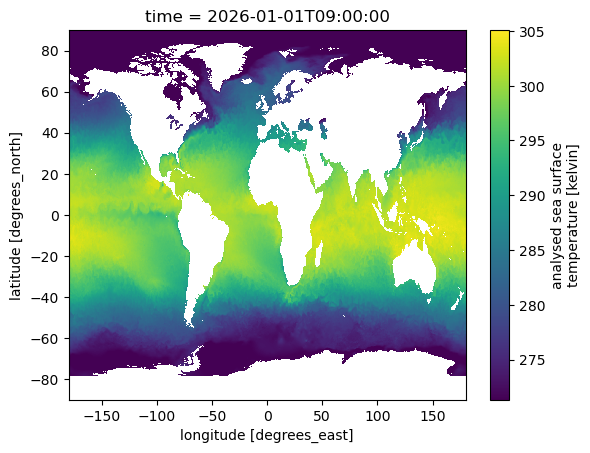

In [75]:
data["analysed_sst"].isel(time=0).plot()